# Solución del laboratorio 2: Virginia Mason: priorizar mejora y reducir reproceso
**Profesor de laboratorio: Manuel López.** Material docente.
Los resultados guardados corresponden a la ejecución del mismo código en Python. Abra el notebook desde esta carpeta para conservar las rutas relativas.
El desarrollo matemático, la interpretación y la pauta de corrección están en el archivo .tex asociado.


pareto_frecuencia
               tipo  frecuencia  costo_unitario_um  costo_total_um  porcentaje  acumulado_pct
             demora          40                  5             200        40.0           40.0
registro_incompleto          25                 12             300        25.0           65.0
       falta_insumo          20                 20             400        20.0           85.0
          reproceso          15                 30             450        15.0          100.0

pareto_costo_total_um
               tipo  frecuencia  costo_unitario_um  costo_total_um  porcentaje  acumulado_pct
          reproceso          15                 30             450   33.333333      33.333333
       falta_insumo          20                 20             400   29.629630      62.962963
registro_incompleto          25                 12             300   22.222222      85.185185
             demora          40                  5             200   14.814815     100.000000

carteras
cartera 

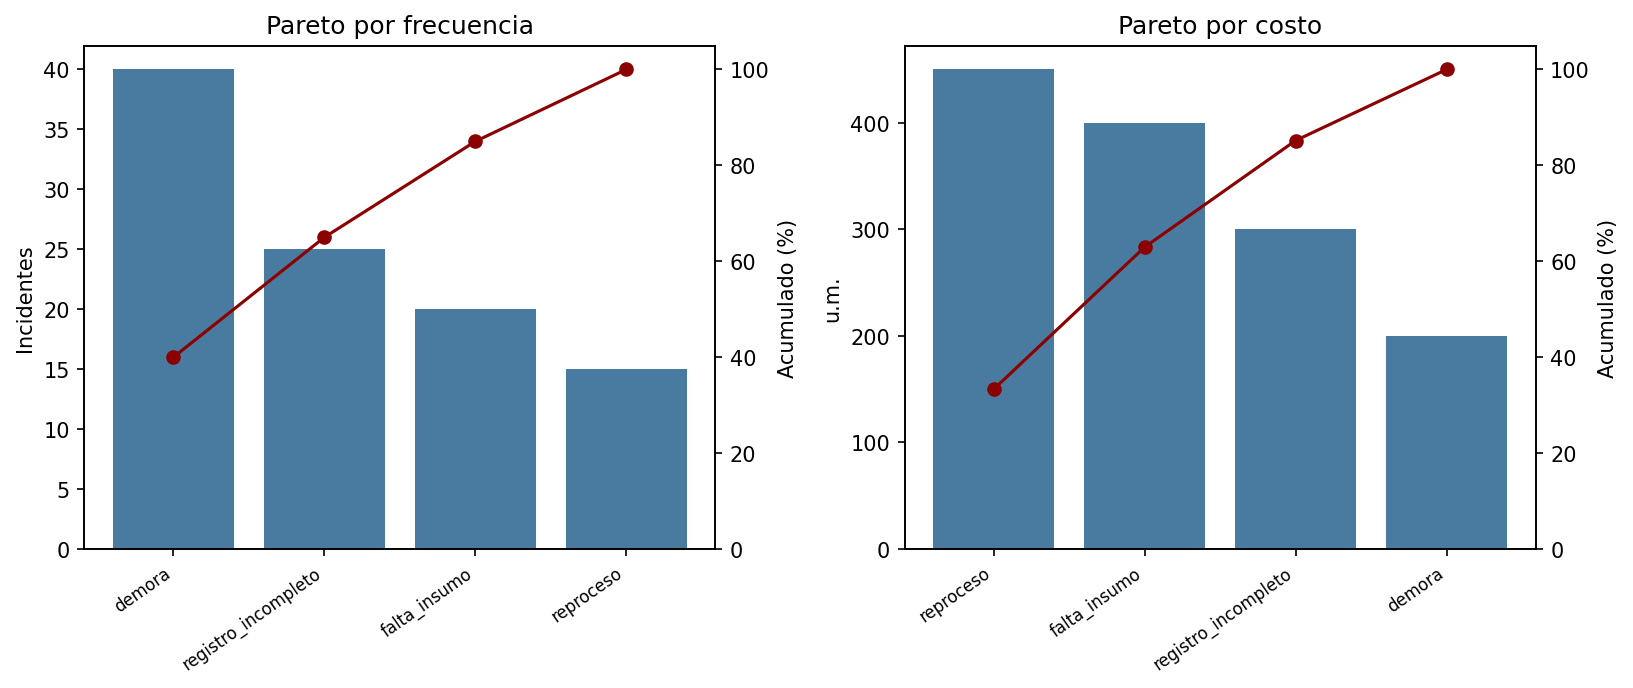

In [1]:
"""Solución docente de Gestión de Operaciones. Profesor: Manuel López."""
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
datos = base / "datos"
salida = base / "resultados"
salida.mkdir(exist_ok=True)
parametros = json.loads((datos / "parametros.json").read_text(encoding="utf-8"))

def tabla(df, nombre):
    df.to_csv(salida / (nombre + ".csv"), index=False)
    visible = df if len(df) <= 28 else df.head(12)
    print("\n" + nombre + "\n" + visible.to_string(index=False))
    if len(df) > 28:
        print(f"Vista inicial: {len(df)} filas completas en {nombre}.csv")

def figura(fig, nombre):
    fig.tight_layout()
    fig.savefig(salida / (nombre + ".png"), dpi=150, bbox_inches="tight")
    if "__file__" not in globals():
        plt.show()
    plt.close(fig)

def resumen(obj):
    def convertir(x):
        if isinstance(x, np.ndarray):
            return x.tolist()
        if isinstance(x, np.generic):
            return x.item()
        raise TypeError(type(x))
    (salida / "resumen.json").write_text(
        json.dumps(obj, ensure_ascii=False, indent=2, default=convertir),
        encoding="utf-8")

from itertools import product
inc = pd.read_csv(datos / "incidentes.csv")
proy = pd.read_csv(datos / "proyectos.csv")
B = parametros["presupuesto_millones_clp"]
assert inc.frecuencia.ge(0).all() and proy.proyecto.is_unique
inc["costo_total_um"] = inc.frecuencia * inc.costo_unitario_um
fig, axes = plt.subplots(1,2,figsize=(11,4.7))
for ax, variable, titulo in zip(axes,["frecuencia","costo_total_um"],
                              ["Pareto por frecuencia","Pareto por costo"]):
    t = inc.sort_values([variable,"tipo"],ascending=[False,True]).copy()
    t["porcentaje"] = 100*t[variable]/t[variable].sum()
    t["acumulado_pct"] = t.porcentaje.cumsum()
    tabla(t, "pareto_"+variable)
    pos=np.arange(len(t))
    ax.bar(pos,t[variable],color="#497ba1")
    ax.set_xticks(pos,t.tipo,rotation=35,ha="right",fontsize=8)
    ax.set_title(titulo)
    ax.set_ylabel("Incidentes" if variable=="frecuencia" else "u.m.")
    ax2=ax.twinx()
    ax2.plot(pos,t.acumulado_pct,"o-",color="darkred")
    ax2.set_ylim(0,105); ax2.set_ylabel("Acumulado (%)")
figura(fig,"paretos")
filas=[]
for x in product([0,1],repeat=len(proy)):
    costo=float(np.dot(x,proy.inversion_millones_clp))
    beneficio=float(np.dot(x,proy.beneficio_millones_clp))
    elegidos="+".join(proy.loc[np.array(x,dtype=bool),"proyecto"]) or "Ninguno"
    filas.append({"cartera":elegidos,"costo":costo,"beneficio":beneficio,
                  "factible":costo<=B})
carteras=pd.DataFrame(filas)
tabla(carteras,"carteras")
opt=carteras[carteras.factible].sort_values(
    ["beneficio","costo","cartera"],ascending=[False,True,True]).iloc[0]
assert opt.cartera=="A+B" and opt.beneficio==14 and opt.costo==9
resumen({"cartera":opt.cartera,"beneficio":opt.beneficio,"inversion":opt.costo,
         "costo_incidentes":inc.costo_total_um.sum(),"mejora_vs_C":4})
